# COMMEMI 2D-1：随机静位移（TE/TM 相同模式） OT vs MSE 反演对比

使用 `MT2DTrueModels.create_commemi_2d1` 生成标准模型。
**随机选取部分台站**，在 xy/yx（TE/TM）上施加**随机 log10 静位移**（`static_shift_std=0.15`）。
合成观测只生成一次，OT 与 MSE **共用同一套 `obs_data`**。
分别用 **6D OT**（`mode="6dot"`）与 **MSE**（`mode="mse"`）反演并对比。


In [1]:
import os
import sys
import torch
from pathlib import Path
import numpy as np

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "mt2d_inv" / "__init__.py").is_file():
            return p
    raise RuntimeError("Cannot find project root (expected src/mt2d_inv/__init__.py)")

root_path = str(_find_project_root(Path.cwd()))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from src.mt2d_inv import MT2DInverterWeightedCost, MT2DTrueModels
from src.mt2d_inv.io import ExperimentLogger
from src.mt2d_inv.plotting import (
    plot_ot_mse_convergence,
    plot_ot_mse_convergence_from_dirs,
    plot_rho_fitting_from_npz,
    plot_ot_mse_pseudosection_from_npz,
)

logger = ExperimentLogger(
    model_tag="ccmm2d1",
    output_root=Path("test_results"),
)
ot_run_name = "ot1_shift_0.15"
mse_run_name = "mse1_shift_0.15"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")
print(f"Project root: {root_path}")

Running on cuda
Project root: /home/liuxr/论文绘图


In [2]:
# 1) Build COMMEMI 2D-i true model
yn, zn, nza, sig_true = MT2DTrueModels.create_commemi_2d1(
    zn=None,
    yn=None,
    nza=10,
    device=device,
    rho_host=100.0,
    rho_block=10.0,
    y_half_width_m=2000.0,
    z_top_m=10000.0,
    z_bottom_m=30000.0,
)

# 2) Survey setup
freqs = torch.logspace(0, -3.5, 30, device=device)
stations = torch.linspace(-15000.0, 15000.0, 21, device=device)

print(f"Grid (nz, ny): {(len(zn)-1, len(yn)-1)}")
print(f"Stations: {len(stations)}, Freqs: {len(freqs)}")

Grid (nz, ny): (40, 40)
Stations: 21, Freqs: 30


✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
Generating 2D MT synthetic data...
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ 2D data error propagation completed
Computing data weights (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ MSE data weights normalized (mean): scale=5.844943e+01
✓ Synthetic data generated
  -> Impedance noise level: 1.0% (gaussian)
随机静位移受影响台站: [8, 15, 17]
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


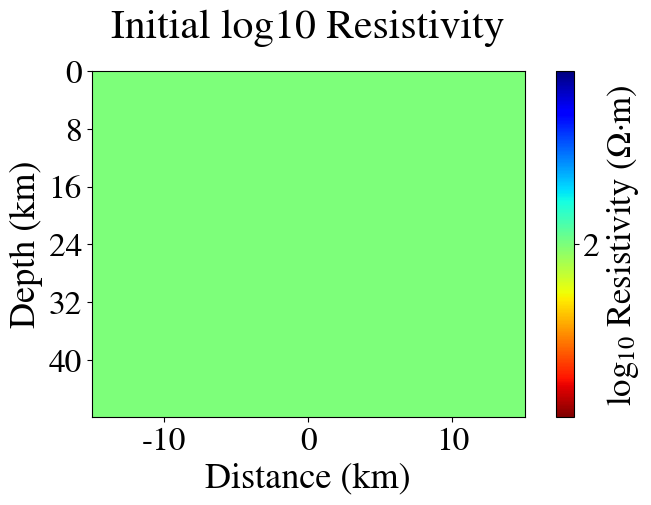

In [3]:
# 3) Inverter + synthetic data（OT/MSE 共用，只生成一次）
inv = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    te_weight=1.0,
    tm_weight=1.0,
    data_loss_scale=10000,
)
inv.set_forward_operator()
inv.sig_true = sig_true
inv.create_synthetic_data(
    noise_level=0.01,
    noise_type="gaussian",
    static_shift_std=0.15,   # 对数域标准差 σ：每台站独立抽取 s~N(0,σ²)，乘子 10^s
    shift_modes=("xy", "yx"),
    shift_stations="random",
    shift_ratio=0.15,
)

# 保存 OT/MSE 共用观测快照
shared_obs_snapshot = {
    "obs_data": {k: v.clone() for k, v in inv.obs_data.items()},
    "data_std": {k: v.clone() if torch.is_tensor(v) else v for k, v in inv.data_std.items()},
}
shared_shift_meta = {
    "shift_mask": inv.shift_mask.clone(),
    "shift_station_ids": list(inv.shift_station_ids),
    "n_shift_stations": inv.n_shift_stations,
    "shift_fraction_actual": inv.shift_fraction_actual,
    "static_shift_std": inv.static_shift_std,
    "shift_ratio": inv.shift_ratio,
    "shift_modes": inv.shift_modes,
    "shift_stations": inv.shift_stations,
    "static_shift_log": {k: v.clone() for k, v in inv.static_shift_log.items()},
    "static_shift_factors": {k: v.clone() for k, v in inv.static_shift_factors.items()},
    "true_data_no_shift": {k: v.clone() for k, v in inv.true_data_no_shift.items()},
    "noise_level": inv.noise_level,
}
print(f"随机静位移受影响台站: {inv.shift_station_ids}")

inv.initialize_model(initial_sigma=0.01)
inv.plot_initial_model(clip_to_stations=True, ylim=[50, 0], synthetic_figwidth_scale=2.0)


In [4]:
# 4a) OT 反演 (6dot)
inv.initialize_model(initial_sigma=0.01)
final_sigma_ot = inv.run_inversion(
    n_epochs=200,
    mode="6dot",
    progress_interval=20,
    current_lambda=1,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
print("OT inversion done")
print(final_sigma_ot.min().item(), final_sigma_ot.max().item())

✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
Epoch 1/200 [   0.5%]
  Elapsed: 0:00:02 | Remaining: ~0:04:51 | ETA: 04:01:26
  Epoch time: 1.46s | Avg: 1.46s
  Total: 1.5514e+01 | Data(6dot): 1.5514e+01
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 10.983 | Rough: 0.00e+00 | Lam: 1.0000000
  OT-distance(6D, view-only): 1.551431e+00
  GradNorms: |g_d|=nan | |λ·g_m|=nan
 [Auto-Lambda] Epoch 10: Adjusted 1.00e+00 -> 5.20e-01 (ratio=2.701e-01)
 [Auto-Lambda] Epoch 20: Adjusted 5.20e-01 -> 2.82e-01 (ratio=2.937e-01)
Epoch 21/200 [  10.5%]
  Elapsed: 0:00:35 | Remaining: ~0:04:54 | ETA: 04:02:03
  Epoch time: 2.05s | Avg: 1.65s
  Total: 6.1858e+00 | Data(6dot): 5.9054e+00
  Misfit(RMS χ²): 9.664 | Rough: 9.96e-01 | Lam: 0.2816966
  OT-distance(6D, view-only): 5.905366e-01
  GradNorms: |g_d|=1.886e-02 | |λ·g_m|=1.979e-0

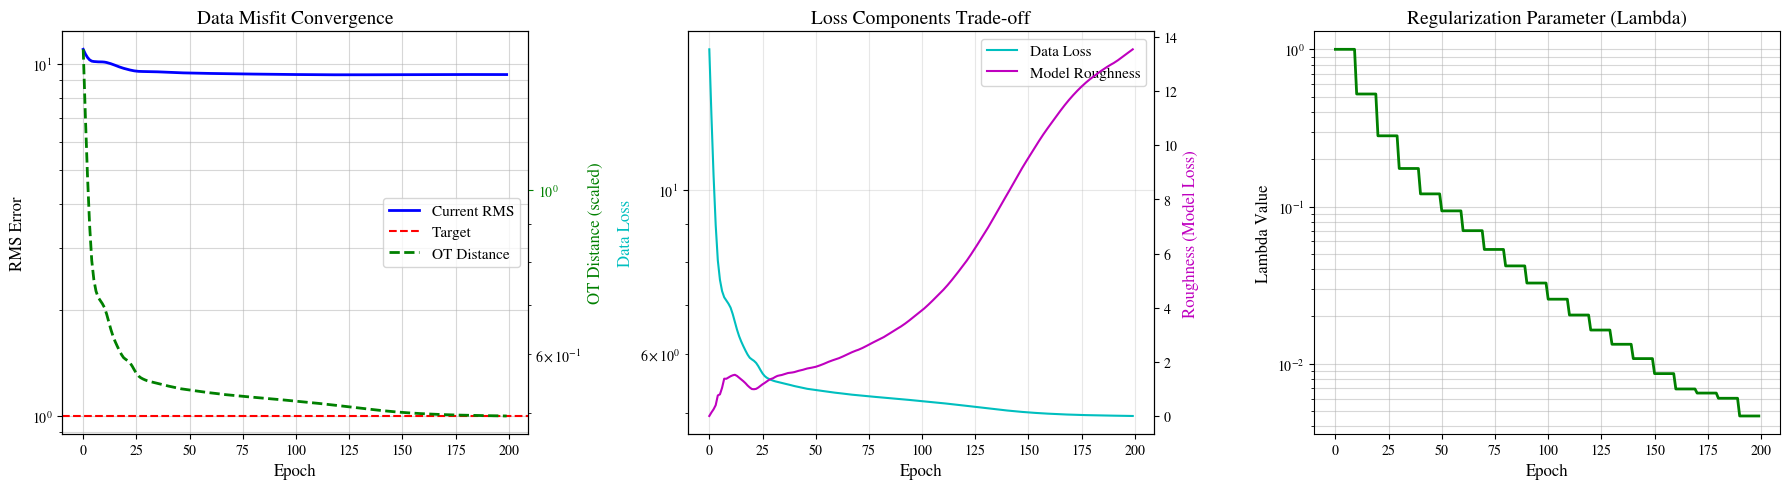

Model structural similarity (SSIM): 0.2110


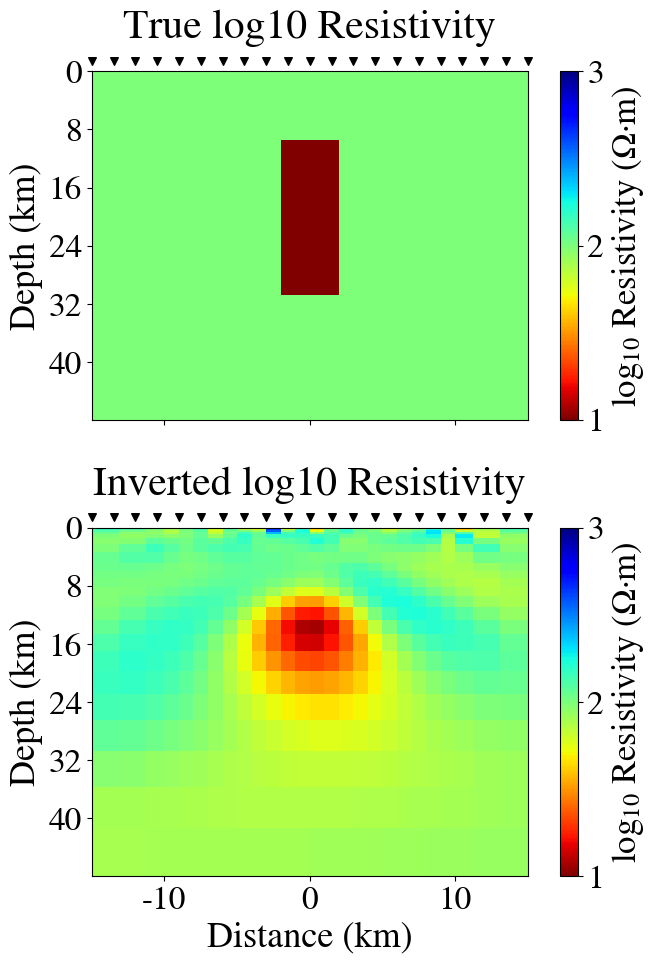

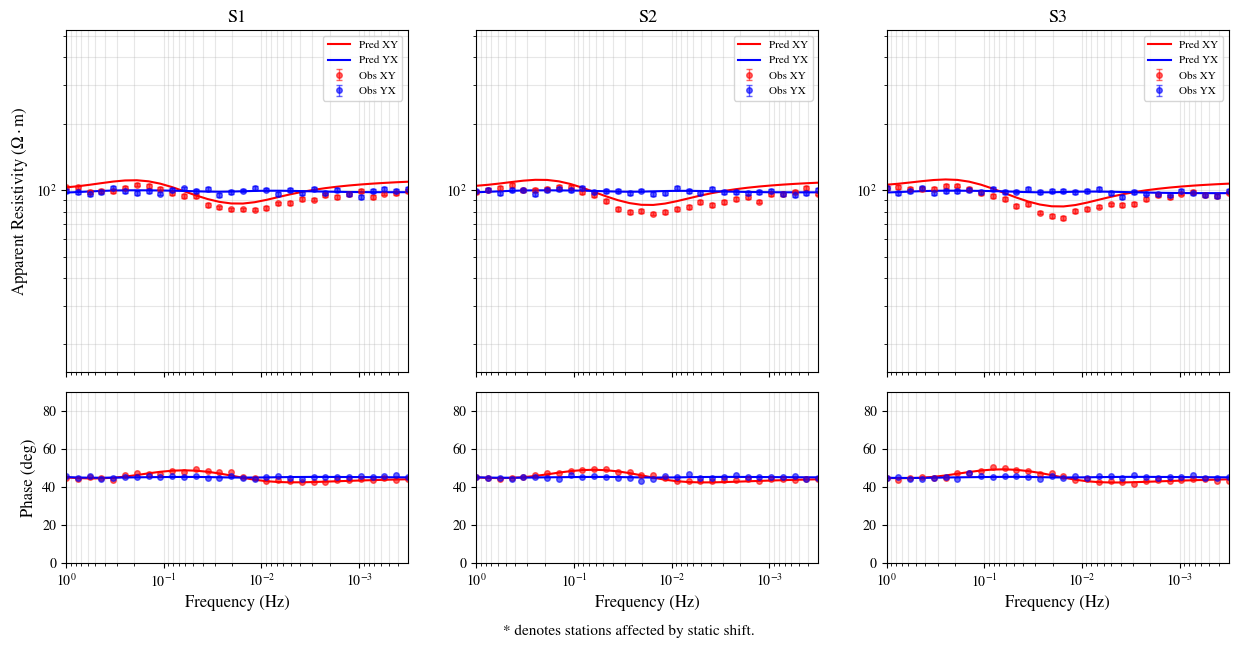

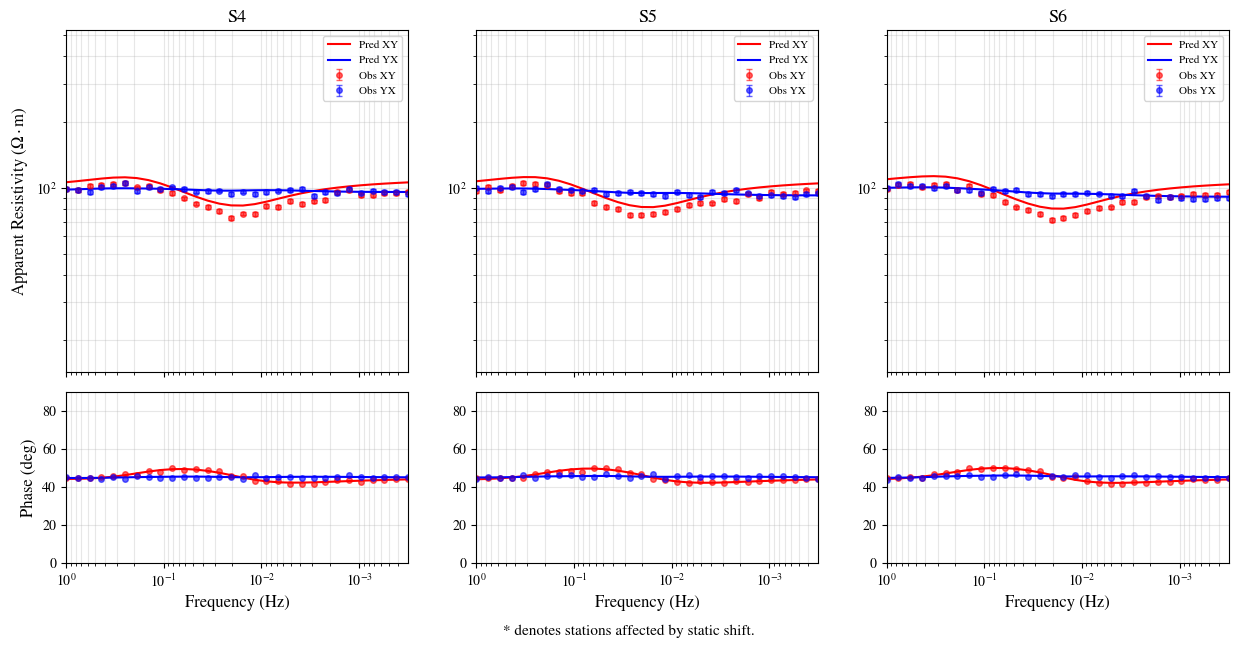

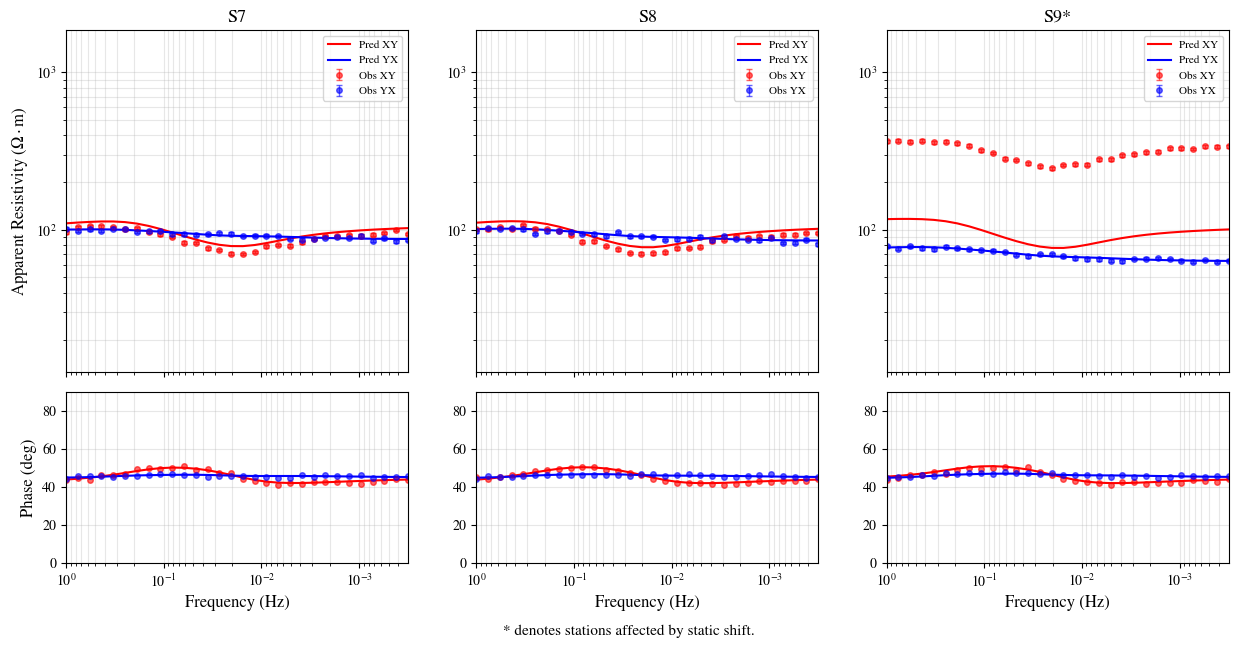

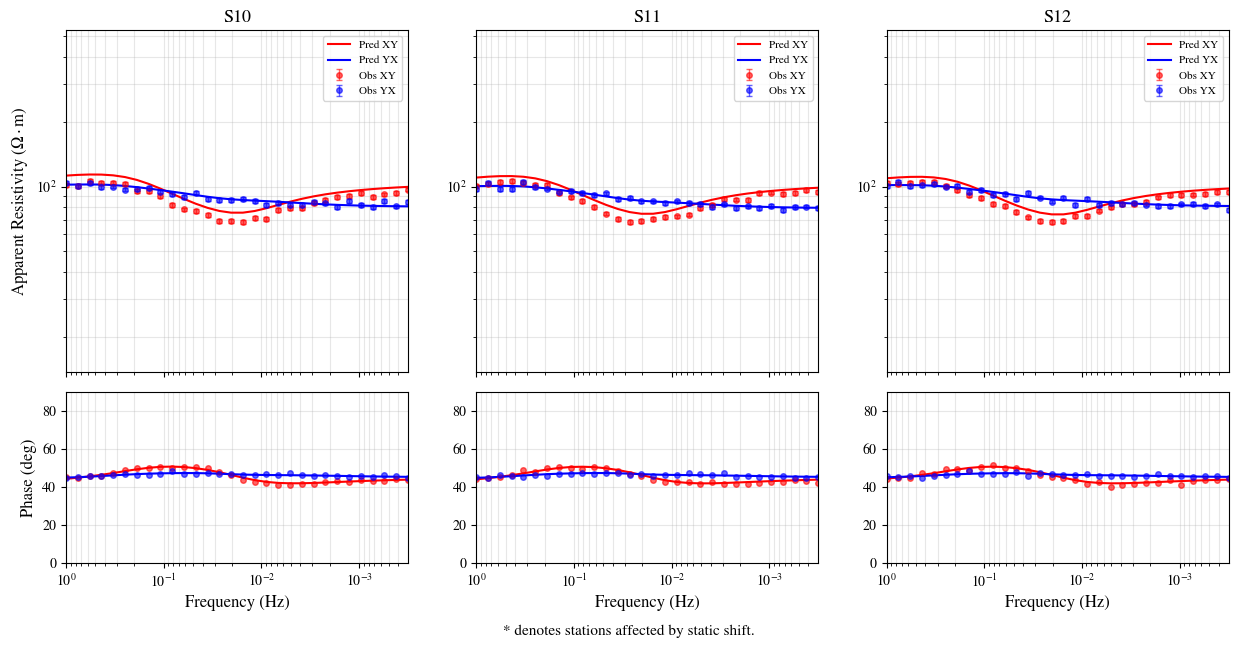

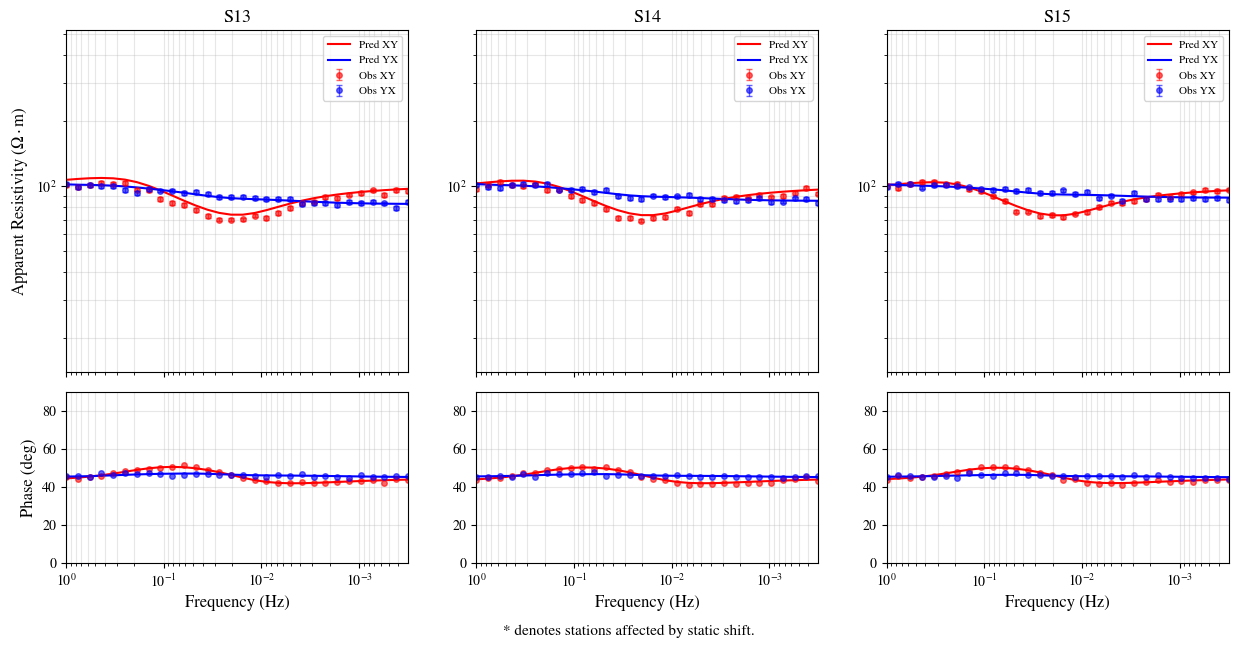

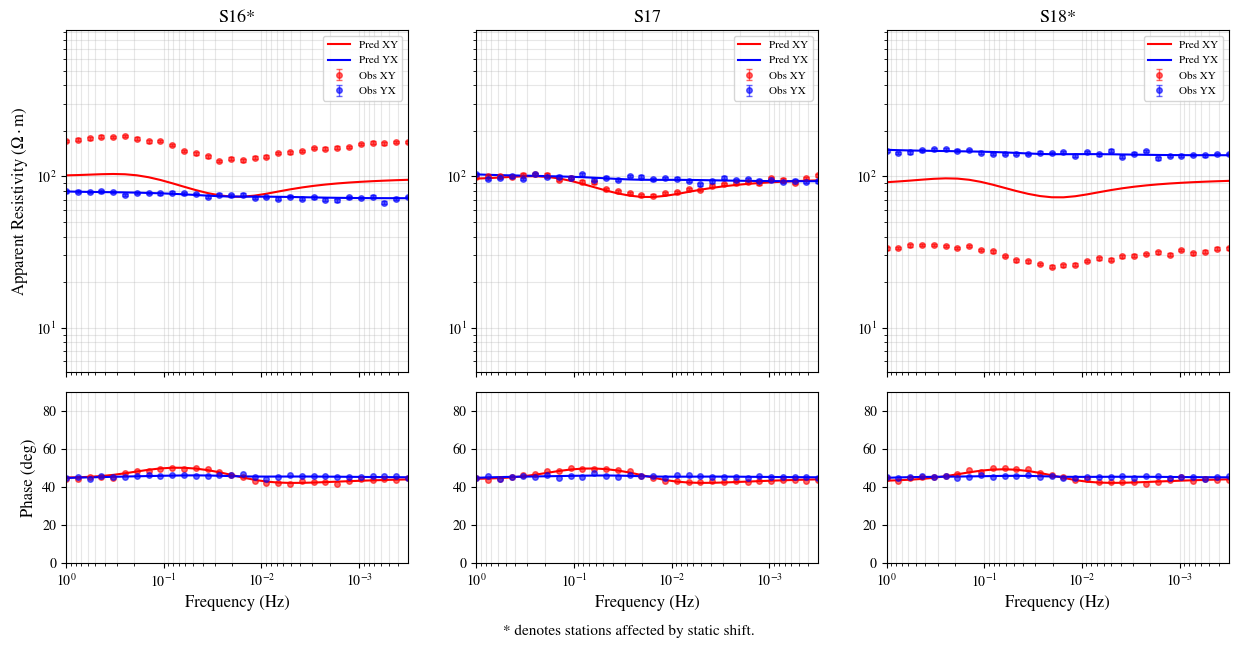

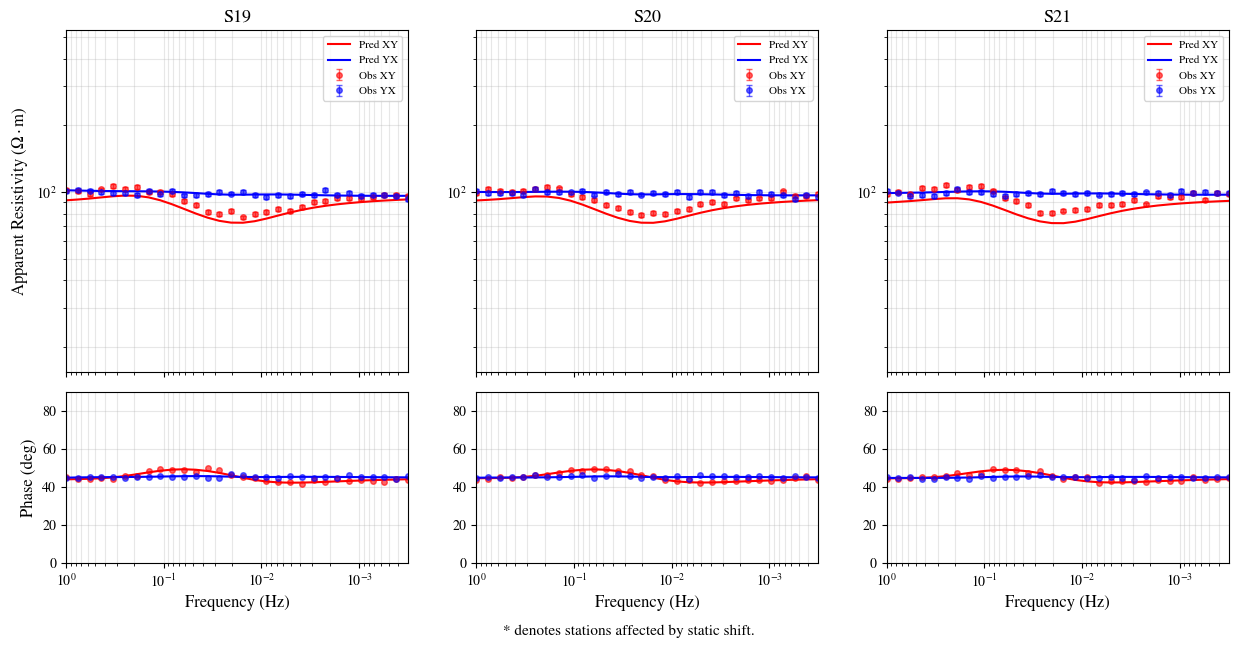

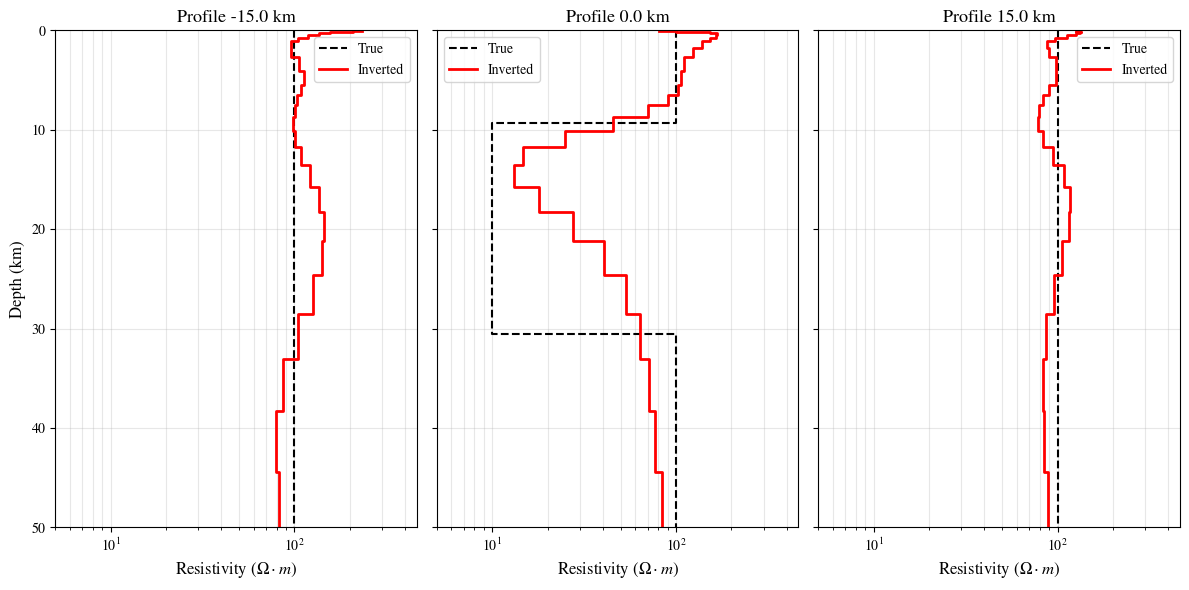

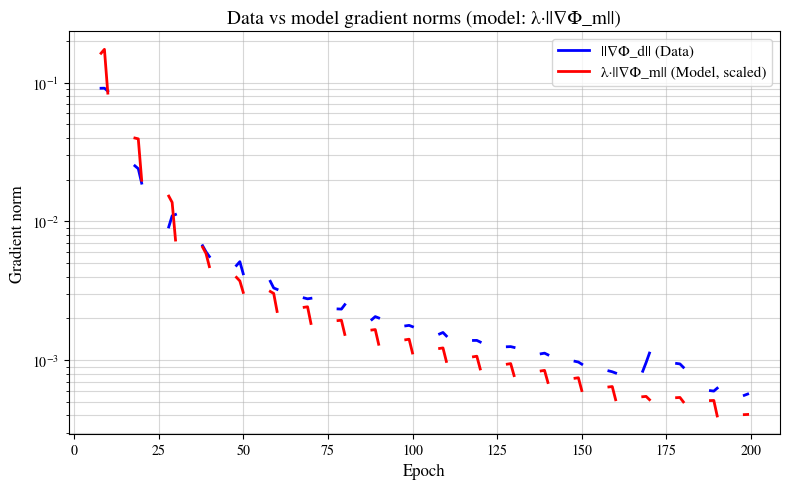

In [5]:
# 5a) OT 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
inv.plot_data_fitting()
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [6]:
# 6a) 保存 OT 结果
ot_run_dir = logger.save_from_inverter(inv, run_name=ot_run_name)
history_ot = list(inv.loss_history)
print(f"OT run saved: {ot_run_dir}")



Saving results to: test_results/ccmm2d1/2026-07-25_04-02-18_ot1_shift_0.15
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
Model structural similarity (SSIM): 0.2110
  ✓ model_comparison.png/.pdf
  ✓ initial_model.png/.pdf
  ✓ data_fitting: 7 plots saved to test_results/ccmm2d1/2026-07-25_04-02-18_ot1_shift_0.15/figures/data_fitting (21 stations)
  ✓ profiles_1d.png/.pdf
  ✓ Figures saved to test_results/ccmm2d1/2026-07-25_04-02-18_ot1_shift_0.15/figures

Results saved successfully!
  Location: test_results/ccmm2d1/2026-07-25_04-02-18_ot1_shift_0.15
  Final RMS χ²: 9.3127
  RMSE: 0.1642
  MAPE: 6.35%

OT run saved: test_results/ccmm2d1/2026-07-25_04-02-18_ot1_shift_0.15


✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ 2D data error propagation completed
Computing data weights (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ MSE data weights normalized (mean): scale=5.844943e+01
✓ Observed data loaded from file
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


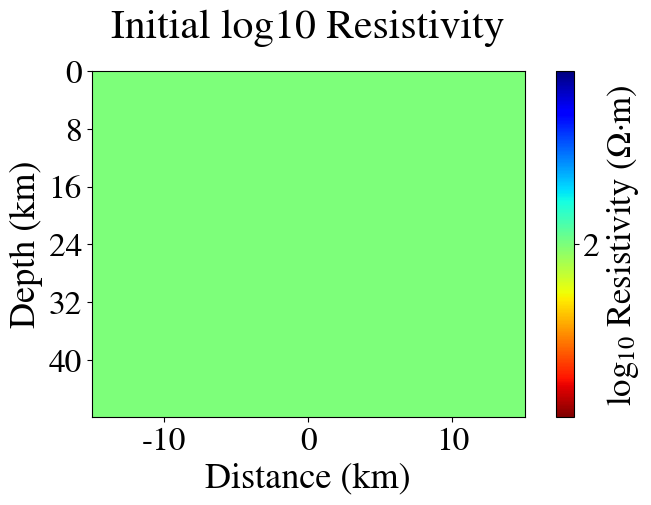

✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
Epoch 1/400 [   0.2%]
  Elapsed: 0:00:01 | Remaining: ~0:09:06 | ETA: 04:11:53
  Epoch time: 1.37s | Avg: 1.37s
  Total: 1.0592e+00 | Data(mse): 1.0592e+00
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 10.983 | Rough: 0.00e+00 | Lam: 0.1000000
  OT-distance(6D, view-only): 1.551431e+00
  GradNorms: |g_d|=nan | |λ·g_m|=nan
 [Auto-Lambda] Epoch 10: Adjusted 1.00e-01 -> 2.65e-02 (ratio=7.048e-02)
 [Auto-Lambda] Epoch 20: Adjusted 2.65e-02 -> 1.38e-02 (ratio=2.690e-01)
Epoch 21/400 [   5.2%]
  Elapsed: 0:00:33 | Remaining: ~0:09:58 | ETA: 04:13:18
  Epoch time: 1.94s | Avg: 1.58s
  Total: 8.1890e-01 | Data(mse): 8.0620e-01
  Misfit(RMS χ²): 9.582 | Rough: 9.22e-01 | Lam: 0.0137691
  OT-distance(6D, view-only): 6.489431e-01
  GradNorms: |g_d|=1.673e-03 | |λ·g_m|=1.649e-03
 [Auto-Lambda] Epoch 30: Adjusted 1.38e-02 -> 1.15e-02 (ratio=7.029e-01)
 [Auto-Lambda] Epoch 

In [7]:
# 4b) MSE 反演（共用 OT 的 obs_data，仅重置初模与损失尺度）
inv_mse = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    data_loss_scale=30,
)
inv_mse.set_forward_operator()
inv_mse.sig_true = sig_true
inv_mse.load_obs_data(shared_obs_snapshot, noise_floor=shared_shift_meta["noise_level"])
for key, val in shared_shift_meta.items():
    if isinstance(val, dict):
        setattr(inv_mse, key, {k: (v.clone() if torch.is_tensor(v) else v) for k, v in val.items()})
    elif torch.is_tensor(val):
        setattr(inv_mse, key, val.clone())
    else:
        setattr(inv_mse, key, val)

inv_mse.initialize_model(initial_sigma=0.01)
inv_mse.plot_initial_model(clip_to_stations=True, ylim=[50, 0], synthetic_figwidth_scale=2.0)

final_sigma_mse = inv_mse.run_inversion(
    n_epochs=400,
    mode="mse",
    progress_interval=20,
    current_lambda=0.1,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
inv = inv_mse  # 供后续 MSE 绘图/导出使用
print("MSE inversion done")
print(final_sigma_mse.min().item(), final_sigma_mse.max().item())


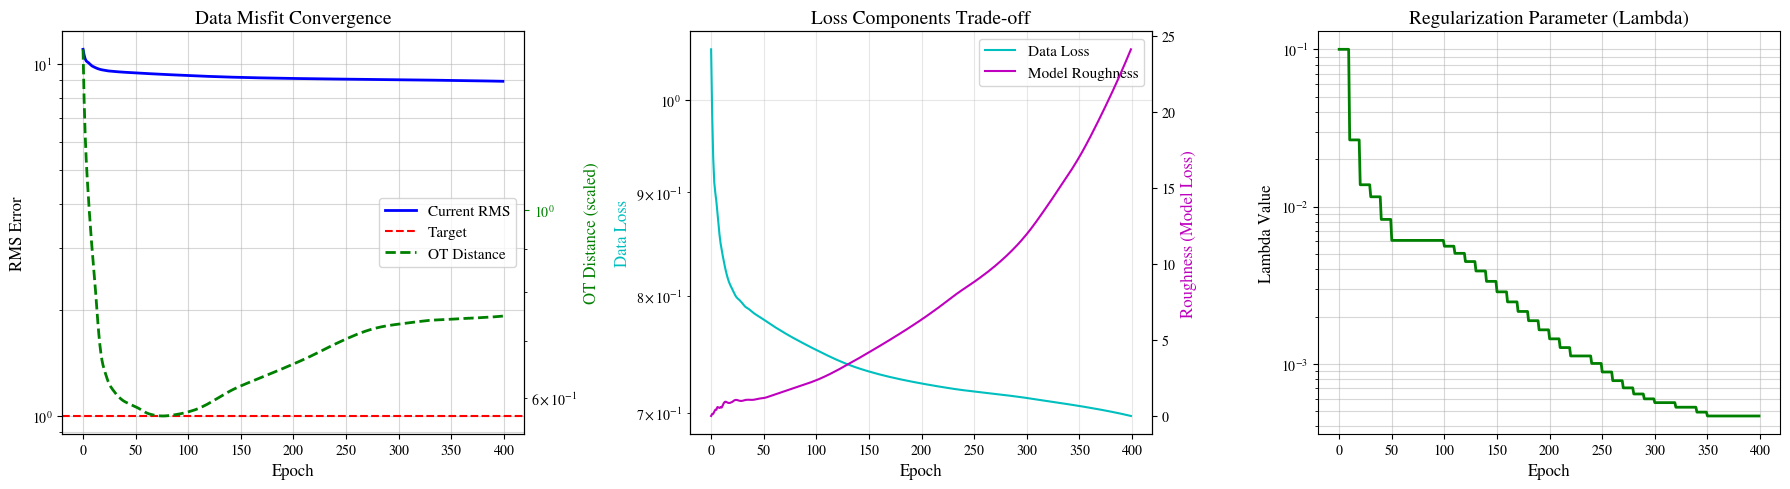

Model structural similarity (SSIM): 0.1224


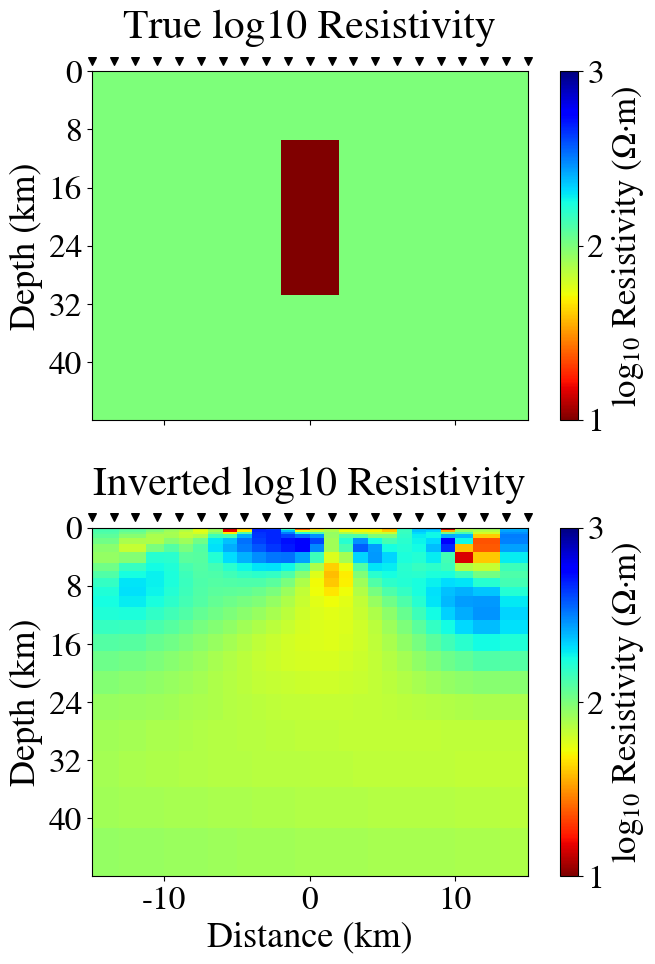

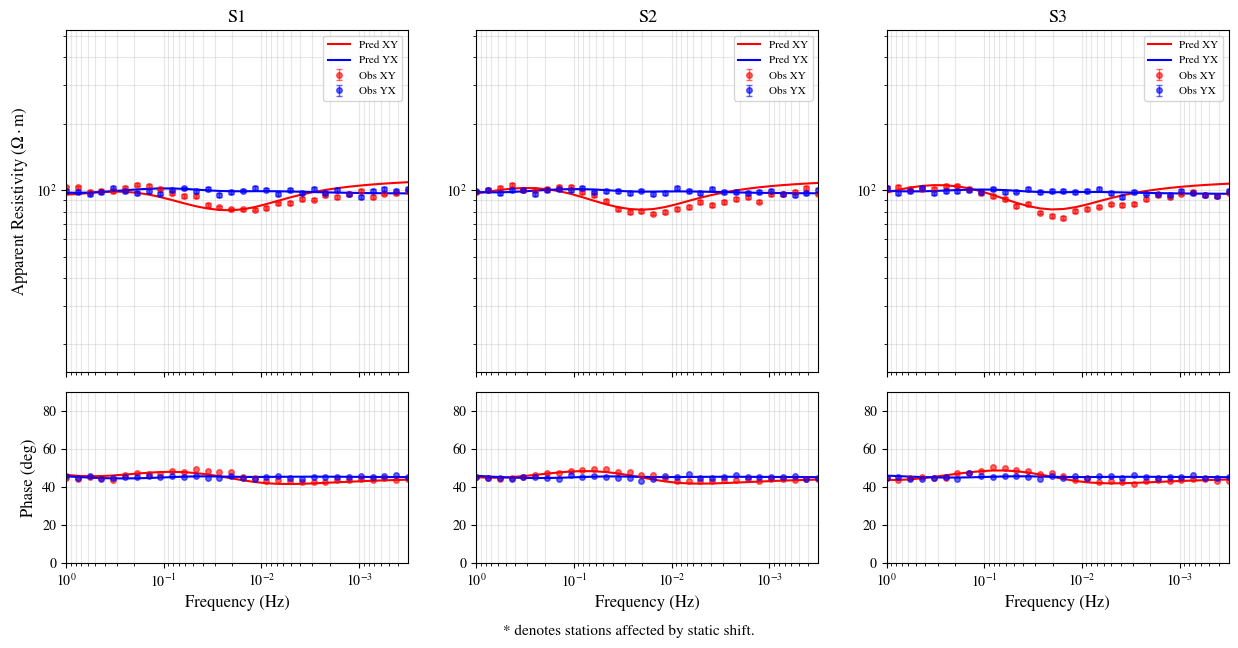

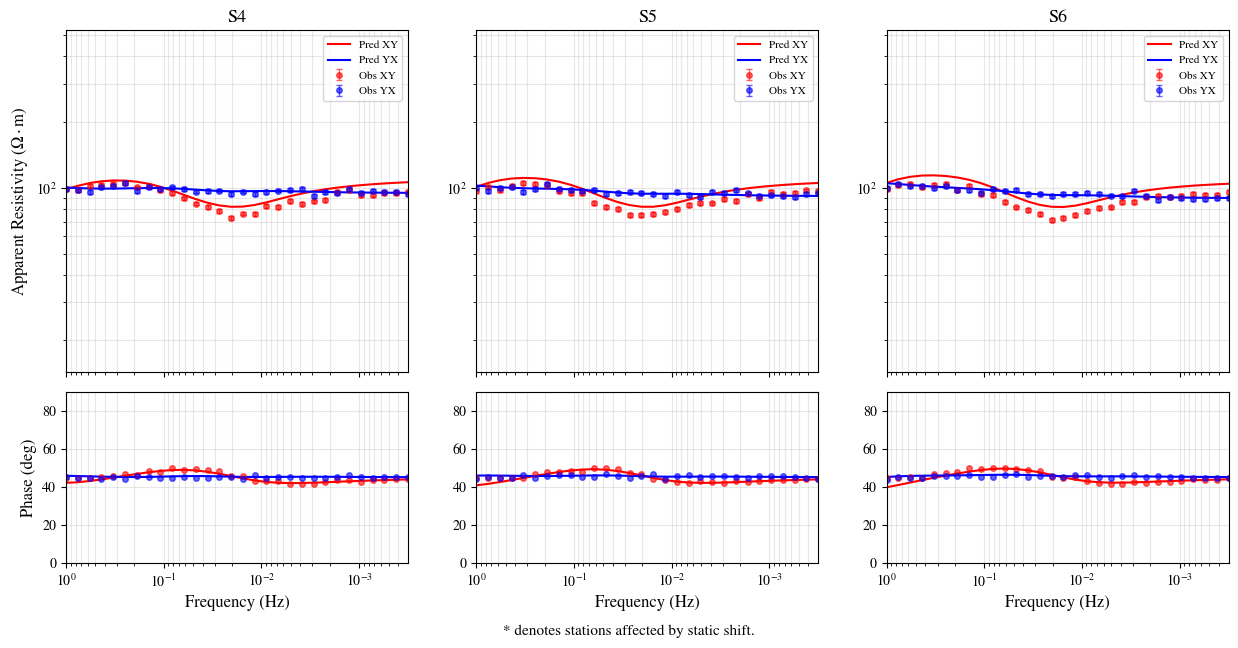

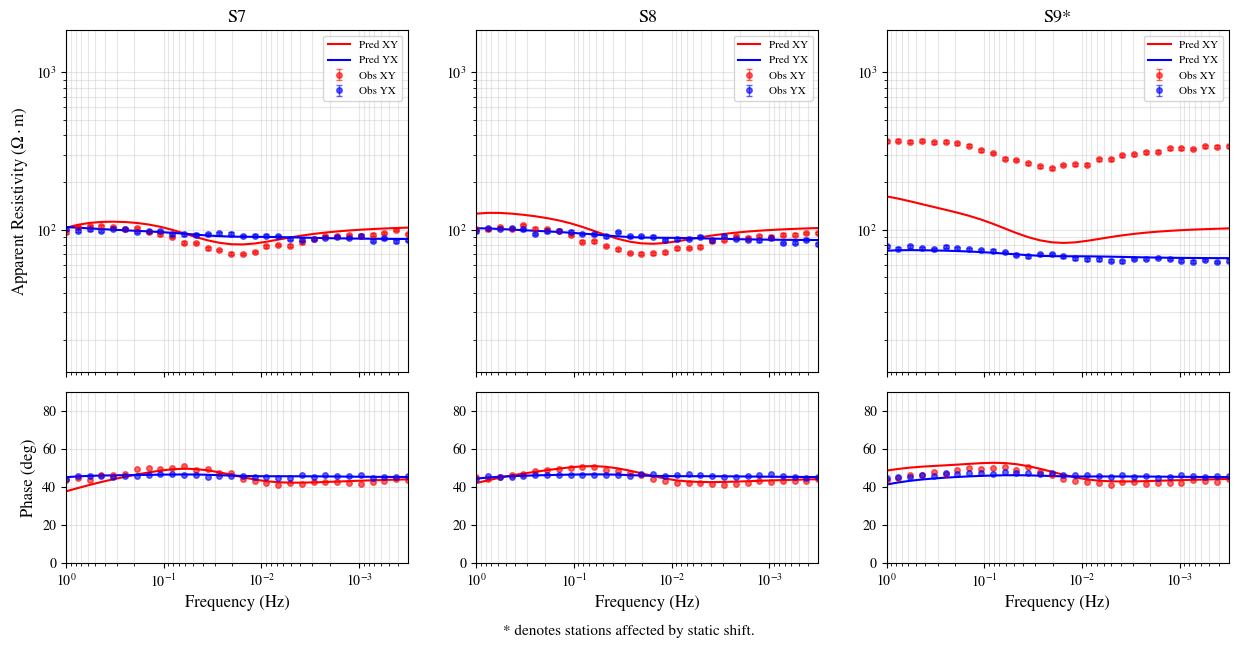

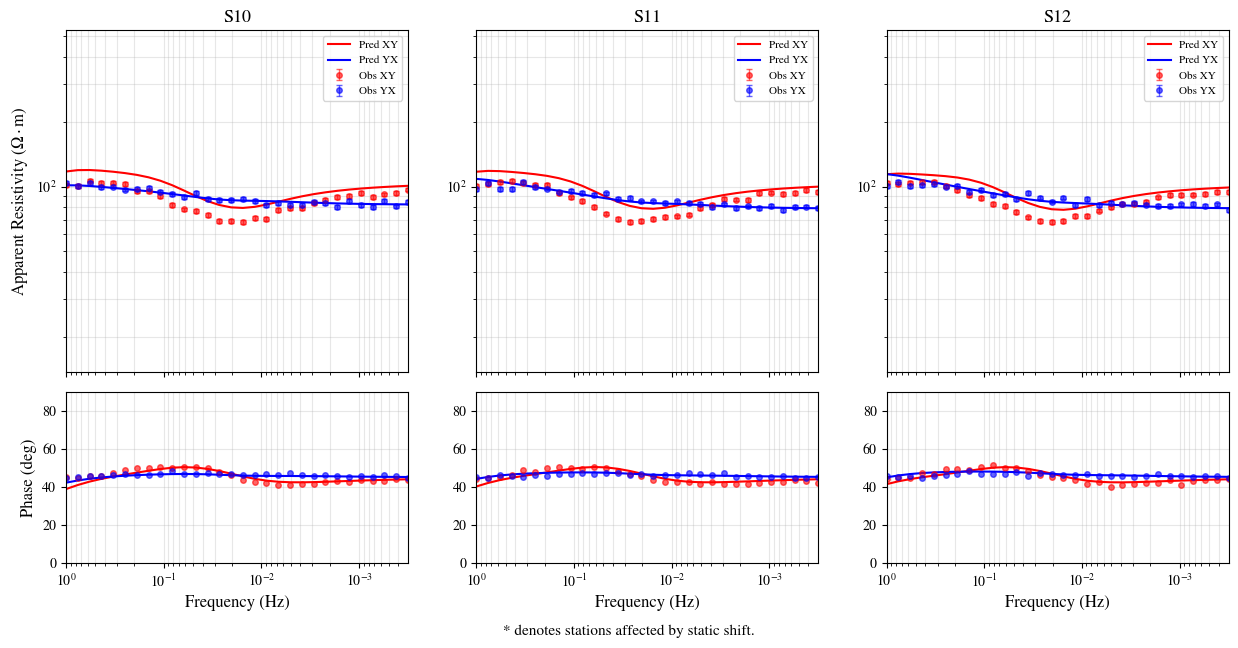

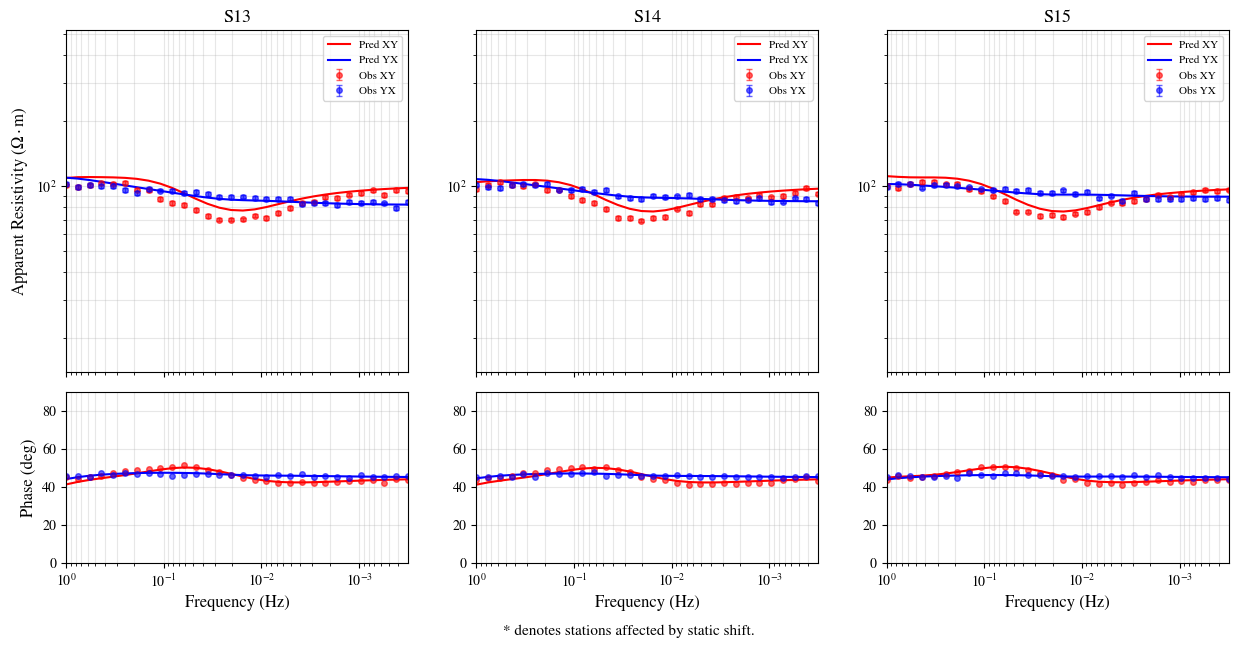

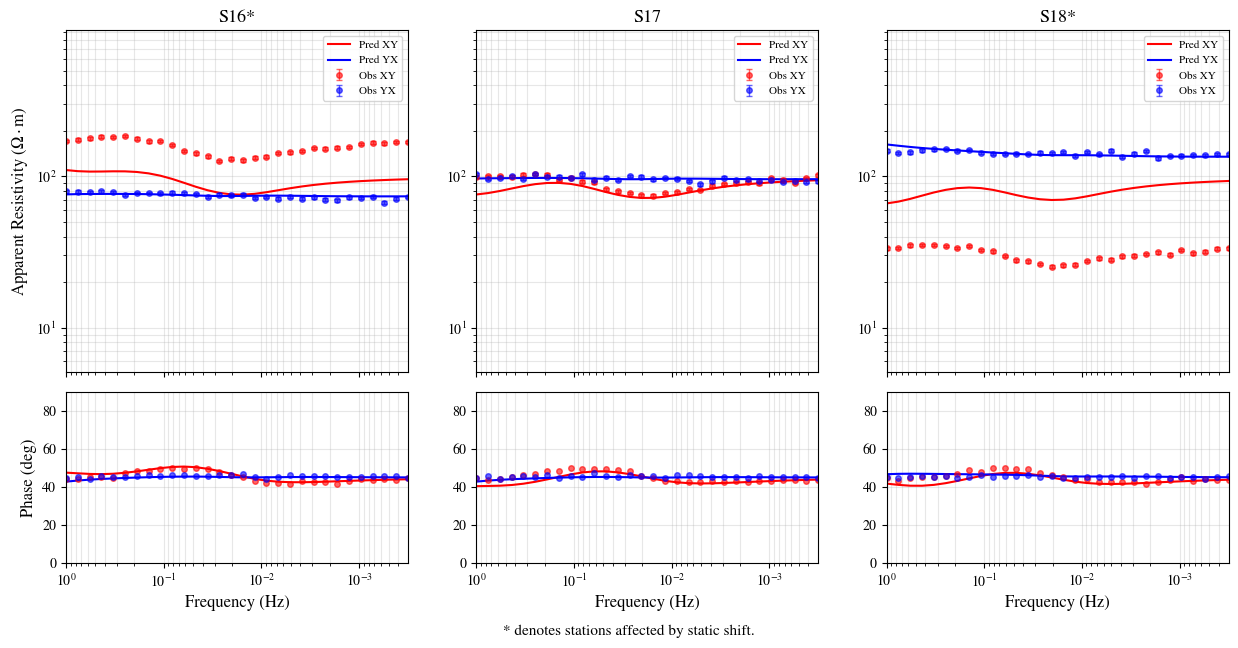

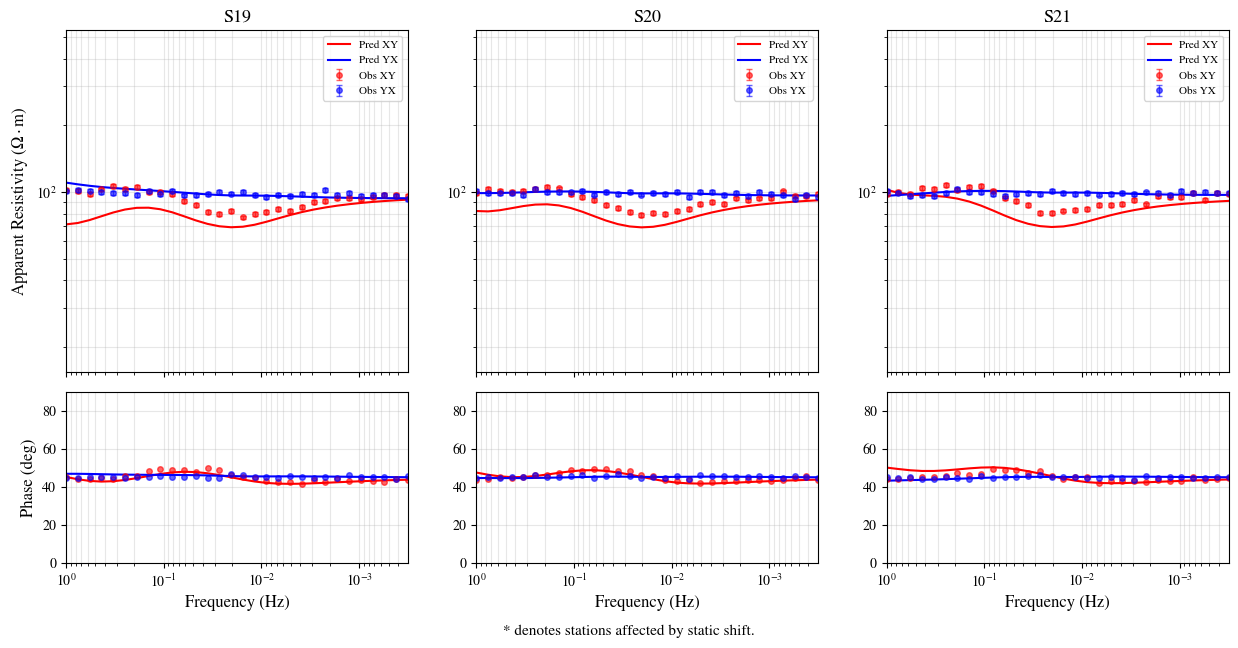

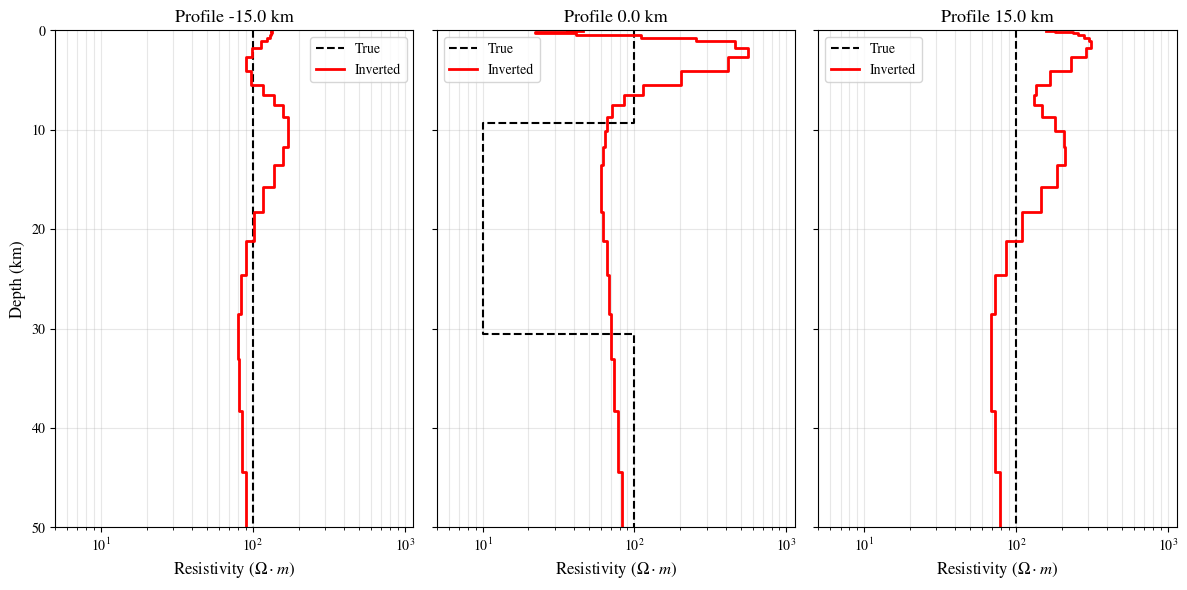

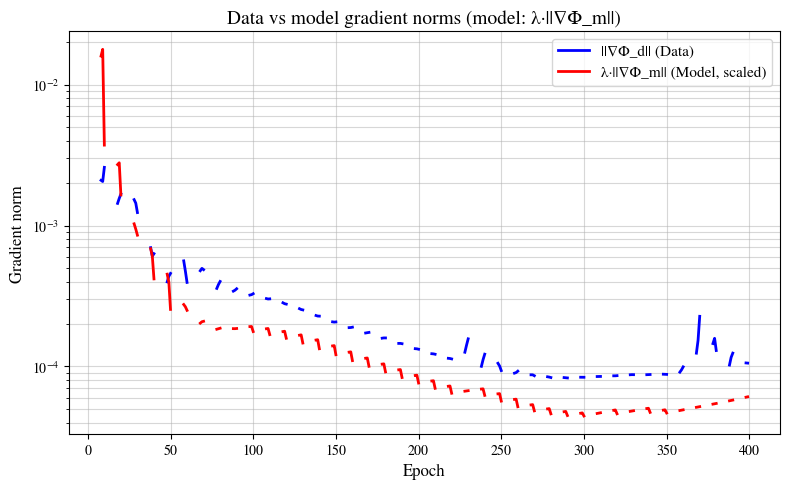

In [8]:
# 5b) MSE 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
inv.plot_data_fitting()
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [9]:
# 6b) 保存 MSE 结果
mse_run_dir = logger.save_from_inverter(inv, run_name=mse_run_name)
history_mse = list(inv.loss_history)
print(f"MSE run saved: {mse_run_dir}")



Saving results to: test_results/ccmm2d1/2026-07-25_04-13-45_mse1_shift_0.15
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
Model structural similarity (SSIM): 0.1224
  ✓ model_comparison.png/.pdf
  ✓ initial_model.png/.pdf
  ✓ data_fitting: 7 plots saved to test_results/ccmm2d1/2026-07-25_04-13-45_mse1_shift_0.15/figures/data_fitting (21 stations)
  ✓ profiles_1d.png/.pdf
  ✓ Figures saved to test_results/ccmm2d1/2026-07-25_04-13-45_mse1_shift_0.15/figures

Results saved successfully!
  Location: test_results/ccmm2d1/2026-07-25_04-13-45_mse1_shift_0.15
  Final RMS χ²: 8.9121
  RMSE: 0.2687
  MAPE: 10.73%

MSE run saved: test_results/ccmm2d1/2026-07-25_04-13-45_mse1_shift_0.15


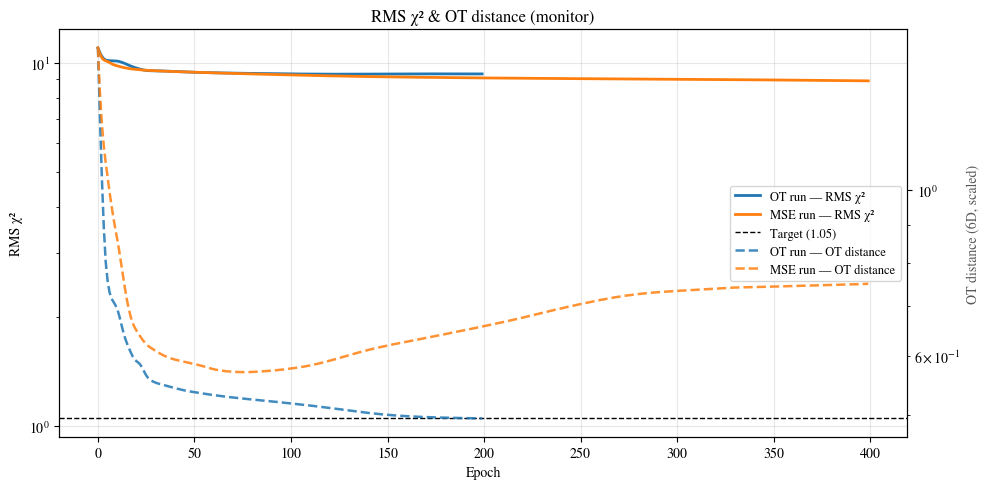

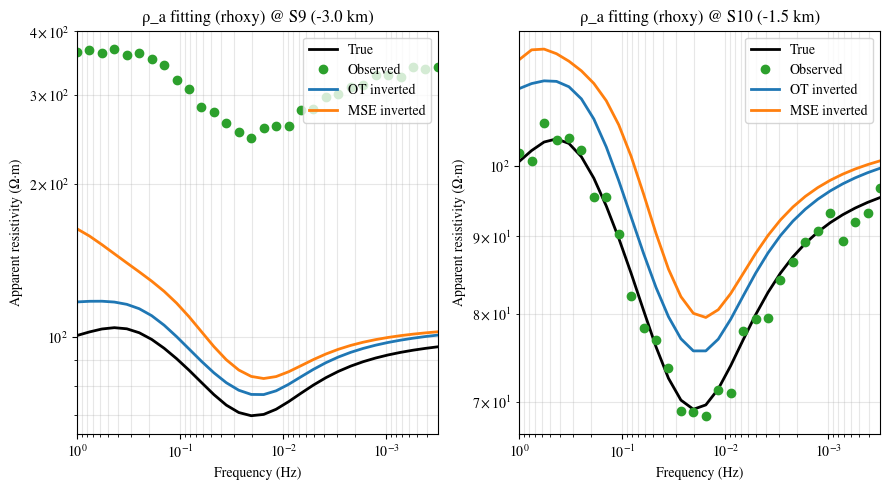

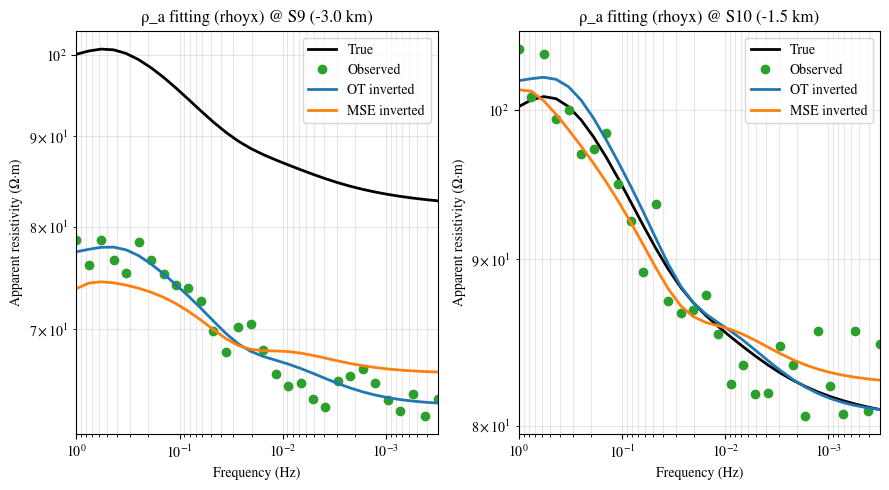

/home/liuxr/论文绘图/src/mt2d_inv/plotting/pseudosection.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


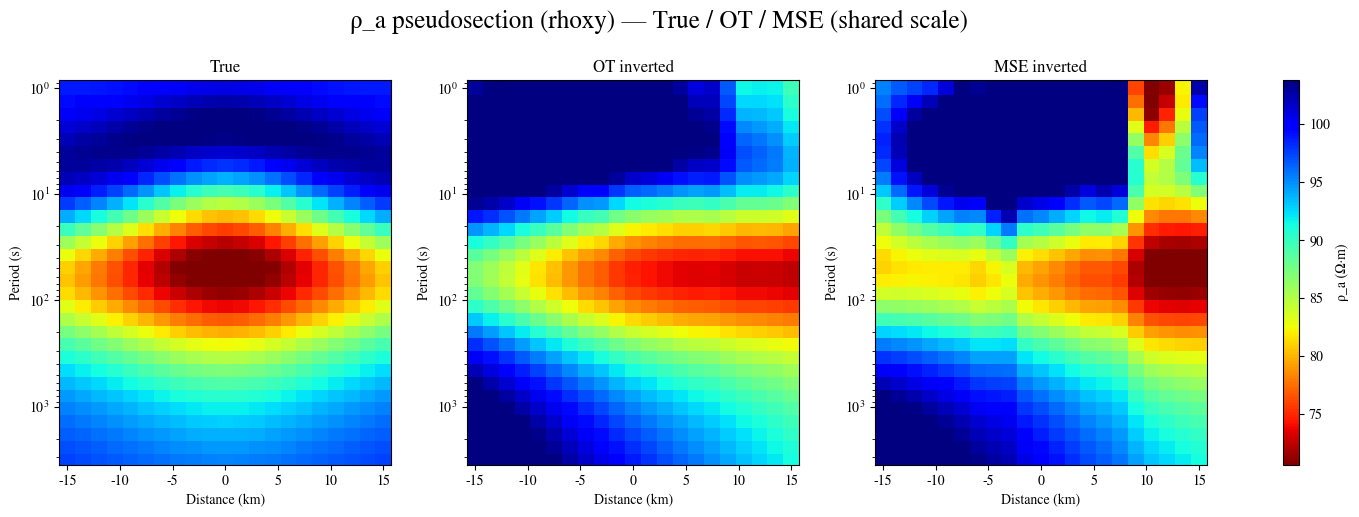

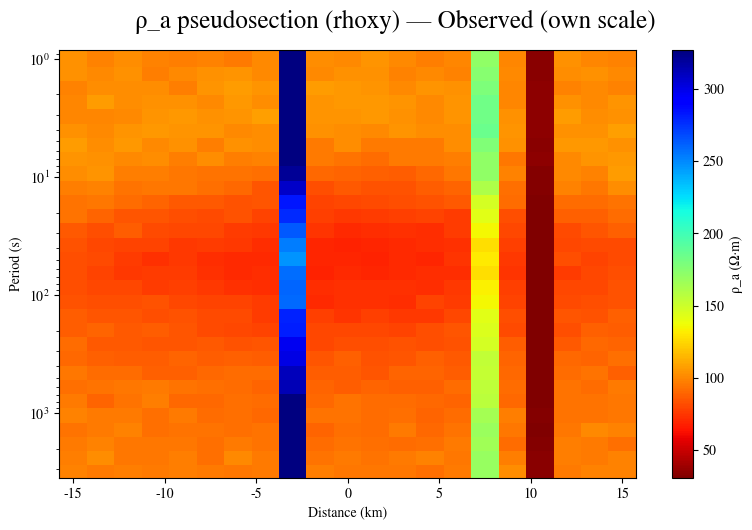

{'inversion_axes': array([<Axes: title={'center': 'True'}, xlabel='Distance (km)', ylabel='Period (s)'>,
        <Axes: title={'center': 'OT inverted'}, xlabel='Distance (km)', ylabel='Period (s)'>,
        <Axes: title={'center': 'MSE inverted'}, xlabel='Distance (km)', ylabel='Period (s)'>],
       dtype=object),
 'observed_axes': <Axes: xlabel='Distance (km)', ylabel='Period (s)'>}

In [10]:
# 7) OT vs MSE 对比（收敛曲线 + 视电阻率四线合一 + 伪断面）
plot_ot_mse_convergence(history_ot, history_mse, target_misfit=1.05)

plot_rho_fitting_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    station_idx=[8,9],
    mode="xy",
)
plot_rho_fitting_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    station_idx=[8,9],
    mode="yx",
)

plot_ot_mse_pseudosection_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    mode="xy",
)